# Step 01 — Data Loading & Preprocessing
### Statistical POS Tagging using HMMs · 23BCS052 · Hammad Malik

---

**What we do in this notebook:**
1. Install and import all required libraries
2. Load the Penn Treebank corpus via NLTK
3. Explore the data — understand what it looks like
4. Extract (word, tag) pairs and clean them
5. Split into Train / Test sets (80 / 20)
6. Analyse tag frequency distribution
7. Measure OOV (unknown word) rate
8. Save everything for the next notebook

> **Mental model:** The Penn Treebank is like a giant textbook where every sentence is already answered — every word has its correct POS tag. This notebook opens that textbook, reads it, and splits it into a *study set* (train) and an *exam set* (test).

---
## Cell 1 — Install Dependencies
Run this once. You will not need to run it again after the first time.

In [ ]:
import subprocess
subprocess.run(['pip', 'install', 'nltk', 'matplotlib', 'pandas'], check=True)
print('All packages installed.')

All packages installed.


---
## Cell 2 — Import Libraries

In [ ]:
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from collections import Counter
import random
import pickle

# Fixed seed — ensures our train/test split is identical every run
random.seed(42)
np.random.seed(42)

print(f'NLTK version  : {nltk.__version__}')
print(f'NumPy version : {np.__version__}')

NLTK version  : 3.9.1
NumPy version : 2.0.2


---
## Cell 3 — Download the Penn Treebank

> **What is the treebank sample?**  
> NLTK ships a free 10% sample of the Penn Treebank — around 3,900 sentences, ~100,000 words. That is more than enough to train and evaluate our HMM for a course project. The full corpus (1M words) requires an LDC license.

In [ ]:
nltk.download('treebank')
nltk.download('universal_tagset')

from nltk.corpus import treebank

print(f'\nTotal tagged sentences : {len(treebank.tagged_sents()):,}')
print(f'Total tagged words     : {len(treebank.tagged_words()):,}')

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.



Total tagged sentences : 3,914
Total tagged words     : 100,676


---
## Cell 4 — Peek at the Raw Data

Always look at your data before doing anything to it. This is a good habit in every ML project.

In [ ]:
all_sentences = treebank.tagged_sents()

print('First 3 sentences in the corpus:')
print('=' * 55)

for i, sent in enumerate(all_sentences[:3]):
    print(f'\nSentence {i+1}:')
    for word, tag in sent:
        print(f'  {word:<22} {tag}')

print('\nEach sentence is a list of (word, tag) tuples.')
print(f'First tuple of sentence 1: {all_sentences[0][0]}')

First 3 sentences in the corpus:

Sentence 1:
  Pierre                 NNP
  Vinken                 NNP
  ,                      ,
  61                     CD
  years                  NNS
  old                    JJ
  ,                      ,
  will                   MD
  join                   VB
  the                    DT
  board                  NN
  as                     IN
  a                      DT
  nonexecutive           JJ
  director               NN
  Nov.                   NNP
  29                     CD
  .                      .

Sentence 2:
  Mr.                    NNP
  Vinken                 NNP
  is                     VBZ
  chairman               NN
  of                     IN
  Elsevier               NNP
  N.V.                   NNP
  ,                      ,
  the                    DT
  Dutch                  NNP
  publishing             VBG
  group                  NN
  .                      .

Sentence 3:
  Rudolph                NNP
  Agnew                  

---
## Cell 5 — Clean the Tags

> **Why clean?**  
> Penn Treebank tags sometimes carry extra suffixes like `-SBJ` (subject) or `-TMP` (temporal).  
> Example: `NNP-SBJ` just means "Proper Noun that happens to be the subject" — for POS tagging we only care that it is an `NNP`. We strip the suffix to reduce noise.

In [ ]:
def clean_tag(tag):
    """
    Strip function-tag suffixes from Penn Treebank tags.
    'NNP-SBJ' -> 'NNP' | 'VBD-TMP' -> 'VBD' | 'NN' -> 'NN'
    """
    return tag.split('-')[0].split('=')[0]


def clean_sentence(tagged_sent):
    """
    Clean every (word, tag) pair in a sentence.
    Lowercases the word and strips tag suffixes.
    """
    return [(word.lower(), clean_tag(tag)) for word, tag in tagged_sent]


cleaned_sentences = [clean_sentence(sent) for sent in all_sentences]

print('Before cleaning:', all_sentences[0][:5])
print('After  cleaning:', cleaned_sentences[0][:5])

Before cleaning: [('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS')]
After  cleaning: [('pierre', 'NNP'), ('vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS')]


---
## Cell 6 — Train / Test Split (80 / 20)

> **Why split?**  
> We train our HMM on 80% of sentences, then test on the 20% it has **never seen**.  
> Testing on unseen data gives us an honest accuracy number. Testing on training data would be cheating — the model already memorised those answers.
>
> We shuffle first so the split is not biased toward any particular section of the Wall Street Journal.

In [ ]:
shuffled = cleaned_sentences.copy()
random.shuffle(shuffled)

split_idx = int(len(shuffled) * 0.80)
train_sents = shuffled[:split_idx]
test_sents  = shuffled[split_idx:]

train_tokens = sum(len(s) for s in train_sents)
test_tokens  = sum(len(s) for s in test_sents)

print('=' * 45)
print('  SPLIT SUMMARY')
print('=' * 45)
print(f'  Train sentences : {len(train_sents):>6,}')
print(f'  Test  sentences : {len(test_sents):>6,}')
print(f'  Train tokens    : {train_tokens:>6,}')
print(f'  Test  tokens    : {test_tokens:>6,}')
print('=' * 45)

  SPLIT SUMMARY
  Train sentences :  3,131
  Test  sentences :    783
  Train tokens    : 81,021
  Test  tokens    : 19,655


---
## Cell 7 — Tag Frequency Analysis

> **Why do this?**  
> Tags that appear thousands of times will have well-estimated probabilities.  
> Tags that appear only a handful of times will be harder for the model — and for smoothing to fix.  
> This analysis tells us exactly where our model is on solid ground and where it is not.

In [ ]:
tag_counts = Counter()
for sent in train_sents:
    for word, tag in sent:
        tag_counts[tag] += 1

sorted_tags = sorted(tag_counts.items(), key=lambda x: x[1], reverse=True)

df_tags = pd.DataFrame(sorted_tags, columns=['Tag', 'Count'])
df_tags['Percentage'] = (df_tags['Count'] / df_tags['Count'].sum() * 100).round(2)

print(f'Total unique tags in training set: {len(df_tags)}')
print()
print(df_tags.to_string(index=False))

Total unique tags in training set: 44

 Tag  Count  Percentage
  NN  10618       13.11
  IN   7924        9.78
 NNP   7533        9.30
  DT   6582        8.12
       5528        6.82
 NNS   4859        6.00
  JJ   4696        5.80
   ,   3948        4.87
   .   3101        3.83
  CD   2899        3.58
 VBD   2413        2.98
  RB   2247        2.77
  VB   2067        2.55
  CC   1831        2.26
  TO   1753        2.16
 VBZ   1729        2.13
 VBN   1695        2.09
 PRP   1387        1.71
 VBG   1161        1.43
 VBP   1060        1.31
  MD    763        0.94
 POS    657        0.81
PRP$    606        0.75
   $    586        0.72
  ``    575        0.71
  ''    559        0.69
   :    478        0.59
 WDT    352        0.43
 JJR    298        0.37
  WP    198        0.24
NNPS    192        0.24
  RP    170        0.21
 JJS    147        0.18
 WRB    135        0.17
 RBR    108        0.13
  EX     71        0.09
 RBS     33        0.04
 PDT     21        0.03
   #     13        0.02
 

---
## Cell 8 — Visualise Tag Distribution

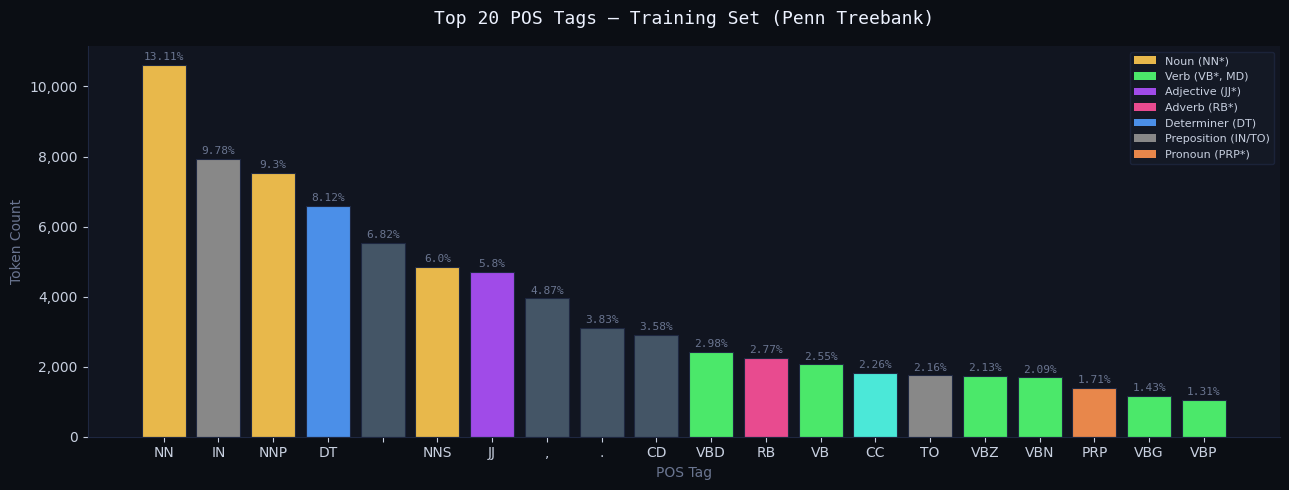

Chart saved as tag_distribution.png


In [ ]:
top_n   = 20
top_tags = df_tags.head(top_n)

def tag_color(tag):
    if tag.startswith('NN'):              return '#e8b84b'  # Noun    — gold
    if tag.startswith('VB') or tag=='MD': return '#4be86a'  # Verb    — green
    if tag.startswith('JJ'):              return '#a04be8'  # Adj     — purple
    if tag.startswith('RB'):              return '#e84b8f'  # Adv     — pink
    if tag in ('DT', 'PDT'):             return '#4b8fe8'  # Det     — blue
    if tag in ('IN', 'TO'):              return '#888888'  # Prep    — grey
    if tag.startswith('PRP'):            return '#e8874b'  # Pronoun — orange
    if tag == 'CC':                       return '#4be8d8'  # Conj    — teal
    return '#445566'

colors = [tag_color(t) for t in top_tags['Tag']]

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0b0e14')
ax.set_facecolor('#111520')

bars = ax.bar(top_tags['Tag'], top_tags['Count'], color=colors,
              edgecolor='#1e2740', linewidth=0.8)

for bar, (_, row) in zip(bars, top_tags.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f"{row['Percentage']}%", ha='center', va='bottom',
            fontsize=8, color='#6a7590', fontfamily='monospace')

ax.set_title(f'Top {top_n} POS Tags — Training Set (Penn Treebank)',
             color='#edf2ff', fontsize=13, pad=16, fontfamily='monospace')
ax.set_xlabel('POS Tag', color='#6a7590', fontsize=10)
ax.set_ylabel('Token Count', color='#6a7590', fontsize=10)
ax.tick_params(colors='#c8d0e0')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#1e2740')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

legend_elements = [
    Patch(facecolor='#e8b84b', label='Noun (NN*)'),
    Patch(facecolor='#4be86a', label='Verb (VB*, MD)'),
    Patch(facecolor='#a04be8', label='Adjective (JJ*)'),
    Patch(facecolor='#e84b8f', label='Adverb (RB*)'),
    Patch(facecolor='#4b8fe8', label='Determiner (DT)'),
    Patch(facecolor='#888888', label='Preposition (IN/TO)'),
    Patch(facecolor='#e8874b', label='Pronoun (PRP*)'),
]
ax.legend(handles=legend_elements, loc='upper right',
          facecolor='#161b27', edgecolor='#1e2740',
          labelcolor='#c8d0e0', fontsize=8)

plt.tight_layout()
plt.savefig('tag_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0b0e14')
plt.show()
print('Chart saved as tag_distribution.png')

---
## Cell 9 — OOV (Unknown Word) Analysis

> **What is OOV?**  
> OOV = Out Of Vocabulary. Some words in the test set will never have appeared during training.  
> Our HMM has no emission probability for these words — it has literally never seen them.  
> This cell measures exactly how big that problem is. Step 03 will solve it with suffix rules.

In [ ]:
train_vocab = set(word for sent in train_sents for word, _ in sent)
test_words  = [word for sent in test_sents  for word, _ in sent]
oov_words   = [w for w in test_words if w not in train_vocab]
oov_rate    = len(oov_words) / len(test_words) * 100

print('=' * 45)
print('  VOCABULARY REPORT')
print('=' * 45)
print(f'  Training vocabulary size : {len(train_vocab):>6,} unique words')
print(f'  Test tokens              : {len(test_words):>6,}')
print(f'  OOV tokens in test       : {len(oov_words):>6,}')
print(f'  OOV rate                 : {oov_rate:>6.2f}%')
print('=' * 45)
print()
print('Sample OOV words (first 20):')
print(list(set(oov_words))[:20])
print()
print('These words will need the suffix-based fallback in Step 03.')

  VOCABULARY REPORT
  Training vocabulary size : 10,108 unique words
  Test tokens              : 19,655
  OOV tokens in test       :  1,368
  OOV rate                 :   6.96%

Sample OOV words (first 20):
['ensure', 'emigrate', 'morale', '36.9', '*t*-38', 'mayland', '3,040,000', 'cohesive', 'lay', '155', 'tenfold', 'novell', 'properties', 'toy', 'mercedes', '8.60', 'unsympathetic', 'transporting', '2.65', 'builds']

These words will need the suffix-based fallback in Step 03.


---
## Cell 10 — Save Everything

We serialise all data structures into a single `.pkl` file.  
Every future notebook loads this file instead of re-running the pipeline.

In [ ]:
data = {
    'train_sents' : train_sents,   # list of [(word, tag), ...]
    'test_sents'  : test_sents,    # list of [(word, tag), ...]
    'train_vocab' : train_vocab,   # set of known words
    'tag_counts'  : dict(tag_counts),
    'all_tags'    : sorted(tag_counts.keys()),
}

with open('pos_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print('Saved to pos_data.pkl')
print()
for key, val in data.items():
    if isinstance(val, (list, set, dict)):
        print(f'  {key:<15} -> {type(val).__name__} with {len(val):,} items')

print()
print('=' * 45)
print('  STEP 01 COMPLETE')
print('  Next -> 02_hmm_training.ipynb')
print('=' * 45)

Saved to pos_data.pkl

  train_sents     -> list with 3,131 items
  test_sents      -> list with 783 items
  train_vocab     -> set with 10,108 items
  tag_counts      -> dict with 44 items
  all_tags        -> list with 44 items

  STEP 01 COMPLETE
  Next -> 02_hmm_training.ipynb


---
## Summary — What just happened?

| Step | What we did | Why |
|------|-------------|-----|
| Load corpus | Read ~3,900 tagged sentences from NLTK's Penn Treebank | This is our labelled training data |
| Peek at data | Printed first 3 sentences raw | Never touch data blind |
| Clean tags | Stripped `-SBJ`, `-TMP` suffixes | Reduces sparsity, keeps tags consistent |
| Split 80/20 | Shuffled and divided into train/test | Model must never see test data during training |
| Tag analysis | Counted and plotted tag frequencies | Understand what the model learns most/least |
| OOV analysis | Measured unseen words in test set | Know the scale of the unknown-word problem |
| Save `.pkl` | Serialised all data structures | So Steps 02-05 load instantly |

---

> **Next notebook:** `02_hmm_training.ipynb`  
> We use `train_sents` to count all tag-to-tag transitions and word-given-tag emissions,  
> then normalise them into the probability matrices that form the HMM.